# Exploracao de Dados Abertos do INSS

Neste notebook eu analiso os dados de beneficios concedidos pelo INSS na competencia 202305 (maio/2023). A ideia foi fazer uma exploracao estatistica simples, mas bem feita, para entender o perfil das concessoes e observar alguns padroes relevantes no conjunto.


## Sobre o dataset escolhido

Escolhi o dataset **Beneficios Concedidos (INSS)**, no arquivo `D.SDA.PDA.001.CON.202305.csv`.

Fonte oficial do dataset:
https://dadosabertos.inss.gov.br/dataset/inss-beneficios-concedidos

Pagina institucional de dados abertos do INSS:
https://www.gov.br/inss/pt-br/acesso-a-informacao/dados-abertos/dados-abertos

Esse conjunto e publicado pelo **Instituto Nacional do Seguro Social (INSS)** e traz informacoes sobre beneficios concedidos. Com ele da para analisar, por exemplo, o tipo de beneficio, sexo, clientela, UF e valor inicial em salarios minimos.

Durante a preparacao, o arquivo ficou com **508.583 registros** e **13 colunas originais** (14 depois da criacao da variavel `idade`).

As variaveis que mais usei na analise foram:
- `competencia_concessao`: mes de referencia da concessao
- `especie`: tipo de beneficio
- `sexo`, `clientela` e `uf`: perfil dos registros
- `qt_sm_rmi`: valor da renda mensal inicial em salarios minimos
- `idade`: variavel derivada a partir da data de nascimento


In [1]:
import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('ggplot')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 140)

CSV_PATH = Path(os.getenv('CSV_PATH', 'data/D.SDA.PDA.001.CON.202305.csv'))



In [2]:

df_raw = pd.read_csv(CSV_PATH, sep=';', encoding='latin1', dtype=str, low_memory=False)

print('Shape original:', df_raw.shape)
print('\nColunas originais:')
print(df_raw.columns.tolist())

df_raw.head()


Shape original: (508583, 13)

Colunas originais:
['Competência concessão', 'Espécie', 'CID', 'Despacho', 'Dt Nascimento', 'Sexo.', 'Clientela', 'Tipo de Cálculo', 'Mun Resid', 'Vínculo dependentes', 'Forma Filiação', 'UF', 'Qt SM RMI']


,Competência concessão,Espécie,CID,Despacho,Dt Nascimento,Sexo.,Clientela,Tipo de Cálculo,Mun Resid,Vínculo dependentes,Forma Filiação,UF,Qt SM RMI
0,202305,Amp. Social Pessoa Portadora Deficiencia,G80.9 Paralisia Cerebral Infantil Ne,Concessao Normal,07/05/2022,Masculino,Urbano,Rmi Informada/Salario Mi,04084-BA-Conceição do Coité,Não Informado,Desempregado,Alagoas,"1,000"
1,202305,Aposentadoria por Idade,Zerados,Concessao Normal,11/02/1963,Masculino,Rural,Rmi Informada/Salario Mi,04237-BA-Paramirim,Não Informado,Segurado Especial,Alagoas,"1,000"
2,202305,Aposentadoria por Idade,Zerados,Concessao em Fase Recursal,09/09/1958,Feminino,Urbano,Calculo Pelas Regras Vig,19214-RS-Taquari,Não Informado,Autônomo,Alagoas,"1,000"
3,202305,Amp. Social Pessoa Portadora Deficiencia,G91 Hidrocefalia,Concessao Normal,04/07/2021,Masculino,Urbano,Rmi Informada/Salario Mi,22029-SE-Itabaiana,Não Informado,Desempregado,Alagoas,"1,000"
4,202305,Amp. Social Pessoa Portadora Deficiencia,F84.0 Autismo Infantil,Concessao Normal,05/01/2016,Masculino,Urbano,Rmi Informada/Salario Mi,05134-CE-Tauá,Não Informado,Desempregado,Alagoas,"1,000"


In [3]:
df = df_raw.copy()

for c in df.columns:
    df[c] = df[c].astype(str).str.strip()

df = df.replace({'nan': np.nan})

orig_cols = df.columns.tolist()
rename_map = {
    orig_cols[0]: 'competencia_concessao',
    orig_cols[1]: 'especie',
    orig_cols[2]: 'cid',
    orig_cols[3]: 'despacho',
    orig_cols[4]: 'dt_nascimento',
    orig_cols[5]: 'sexo',
    orig_cols[6]: 'clientela',
    orig_cols[7]: 'tipo_calculo',
    orig_cols[8]: 'mun_resid',
    orig_cols[9]: 'vinculo_dependentes',
    orig_cols[10]: 'forma_filiacao',
    orig_cols[11]: 'uf',
    orig_cols[12]: 'qt_sm_rmi',
}

df = df.rename(columns=rename_map)

df['qt_sm_rmi'] = (
    df['qt_sm_rmi']
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
)
df['qt_sm_rmi'] = pd.to_numeric(df['qt_sm_rmi'], errors='coerce')

df['dt_nascimento'] = pd.to_datetime(df['dt_nascimento'], format='%d/%m/%Y', errors='coerce')

competencia_moda = str(df['competencia_concessao'].mode().iloc[0])
competencia_data = pd.to_datetime(competencia_moda + '01', format='%Y%m%d') + pd.offsets.MonthEnd(0)
df['idade'] = ((competencia_data - df['dt_nascimento']).dt.days / 365.25)

print('Competência predominante:', competencia_moda, '->', competencia_data.date())
print('Shape após tratamento:', df.shape)
df.head()


Competência predominante: 202305 -> 2023-05-31
Shape após tratamento: (508583, 14)


,competencia_concessao,especie,cid,despacho,dt_nascimento,sexo,clientela,tipo_calculo,mun_resid,vinculo_dependentes,forma_filiacao,uf,qt_sm_rmi,idade
0,202305,Amp. Social Pessoa Portadora Deficiencia,G80.9 Paralisia Cerebral Infantil Ne,Concessao Normal,2022-05-07,Masculino,Urbano,Rmi Informada/Salario Mi,04084-BA-Conceição do Coité,Não Informado,Desempregado,Alagoas,1.0,1.065024
1,202305,Aposentadoria por Idade,Zerados,Concessao Normal,1963-02-11,Masculino,Rural,Rmi Informada/Salario Mi,04237-BA-Paramirim,Não Informado,Segurado Especial,Alagoas,1.0,60.298426
2,202305,Aposentadoria por Idade,Zerados,Concessao em Fase Recursal,1958-09-09,Feminino,Urbano,Calculo Pelas Regras Vig,19214-RS-Taquari,Não Informado,Autônomo,Alagoas,1.0,64.722793
3,202305,Amp. Social Pessoa Portadora Deficiencia,G91 Hidrocefalia,Concessao Normal,2021-07-04,Masculino,Urbano,Rmi Informada/Salario Mi,22029-SE-Itabaiana,Não Informado,Desempregado,Alagoas,1.0,1.905544
4,202305,Amp. Social Pessoa Portadora Deficiencia,F84.0 Autismo Infantil,Concessao Normal,2016-01-05,Masculino,Urbano,Rmi Informada/Salario Mi,05134-CE-Tauá,Não Informado,Desempregado,Alagoas,1.0,7.400411


In [4]:

n_linhas, n_colunas = df.shape
print(f'Registros: {n_linhas:,}'.replace(',', '.'))
print(f'Colunas: {n_colunas}')


Registros: 508.583
Colunas: 14


In [5]:
print('Tipos de dados:')
print(df.dtypes)

print('Valores ausentes por coluna:')
print(df.isna().sum().sort_values(ascending=False))


Tipos de dados:
competencia_concessao               str
especie                             str
cid                                 str
despacho                            str
dt_nascimento            datetime64[us]
sexo                                str
clientela                           str
tipo_calculo                        str
mun_resid                           str
vinculo_dependentes                 str
forma_filiacao                      str
uf                                  str
qt_sm_rmi                       float64
idade                           float64
dtype: object
Valores ausentes por coluna:
competencia_concessao    0
especie                  0
cid                      0
despacho                 0
dt_nascimento            0
sexo                     0
clientela                0
tipo_calculo             0
mun_resid                0
vinculo_dependentes      0
forma_filiacao           0
uf                       0
qt_sm_rmi                0
idade                    0
dty

In [6]:

def estatisticas_descritivas(serie: pd.Series, nome: str):
    s = serie.dropna()
    q1, q2, q3 = s.quantile([0.25, 0.5, 0.75])
    iqr = q3 - q1
    moda = s.mode()
    return pd.Series({
        'variavel': nome,
        'contagem': int(s.count()),
        'media': s.mean(),
        'mediana': s.median(),
        'moda': moda.iloc[0] if not moda.empty else np.nan,
        'minimo': s.min(),
        'maximo': s.max(),
        'desvio_padrao': s.std(),
        'variancia': s.var(),
        'q1': q1,
        'q2_mediana': q2,
        'q3': q3,
        'iqr': iqr,
        'limite_inferior_iqr': q1 - 1.5 * iqr,
        'limite_superior_iqr': q3 + 1.5 * iqr,
    })

stats_qt = estatisticas_descritivas(df['qt_sm_rmi'], 'qt_sm_rmi')
stats_idade = estatisticas_descritivas(df['idade'], 'idade')

stats_df = pd.DataFrame([stats_qt, stats_idade])
stats_df


,variavel,contagem,media,mediana,moda,minimo,maximo,desvio_padrao,variancia,q1,q2_mediana,q3,iqr,limite_inferior_iqr,limite_superior_iqr
0,qt_sm_rmi,508583,1.280181,1.000000,1.00000,0.0010,46.446000,0.669129,0.447733,1.000000,1.000000,1.221000,0.22100,0.668500,1.552500
1,idade,508583,47.296938,49.982204,65.05681,0.1013,109.859001,17.303058,299.395810,33.530459,49.982204,61.237509,27.70705,-8.030116,102.798084


In [7]:

outliers_qt = ((df['qt_sm_rmi'] < stats_qt['limite_inferior_iqr']) | (df['qt_sm_rmi'] > stats_qt['limite_superior_iqr'])).sum()
outliers_idade = ((df['idade'] < stats_idade['limite_inferior_iqr']) | (df['idade'] > stats_idade['limite_superior_iqr'])).sum()

print('Outliers qt_sm_rmi:', int(outliers_qt), f"({outliers_qt/len(df)*100:.2f}%)")
print('Outliers idade:', int(outliers_idade), f"({outliers_idade/len(df)*100:.4f}%)")


Outliers qt_sm_rmi: 81437 (16.01%)
Outliers idade: 12 (0.0024%)


In [8]:

print('qt_sm_rmi -> média:', df['qt_sm_rmi'].mean(), '| mediana:', df['qt_sm_rmi'].median(), '| moda:', df['qt_sm_rmi'].mode().tolist()[:5])
print('idade     -> média:', df['idade'].mean(), '| mediana:', df['idade'].median(), '| moda:', df['idade'].mode().tolist()[:5])


qt_sm_rmi -> média: 1.280181486601007 | mediana: 1.0 | moda: [1.0]
idade     -> média: 47.296938368559424 | mediana: 49.98220396988364 | moda: [65.056810403833]


In [9]:
for col in ['uf', 'especie', 'despacho', 'sexo', 'clientela', 'forma_filiacao']:
    print(f'\nTop 10 de {col}:')
    print(df[col].value_counts(dropna=False).head(10))



Top 10 de uf:
uf
São Paulo            92905
Distrito Federal     81211
Minas Gerais         51887
Rio Grande do Sul    32506
Bahia                32468
Rio de Janeiro       28110
Paraná               27180
Santa Catarina       24241
Pernambuco           16987
Ceará                16908
Name: count, dtype: int64

Top 10 de especie:
especie
Auxílio Doenca Previdenciário               183749
Auxílio Salario Maternidade                  78079
Aposentadoria por Idade                      74336
Pensão por Morte Previdenciária              46956
Amp. Social Pessoa Portadora Deficiencia     33363
Amparo Social ao Idoso                       32796
Aposentadoria por Tempo de Contribuição      20446
Aposentadoria Invalidez Previdenciária       15038
Auxílio Doenca por Acidente do Trabalho      14632
Auxílio Acidente                              3362
Name: count, dtype: int64

Top 10 de despacho:
despacho
Concessao Normal                            345780
Concessao Decorrente de Acao Judicial    

In [10]:
corr = df[['idade', 'qt_sm_rmi']].corr(numeric_only=True)
corr

,idade,qt_sm_rmi
idade,1.000000,0.078532
qt_sm_rmi,0.078532,1.000000


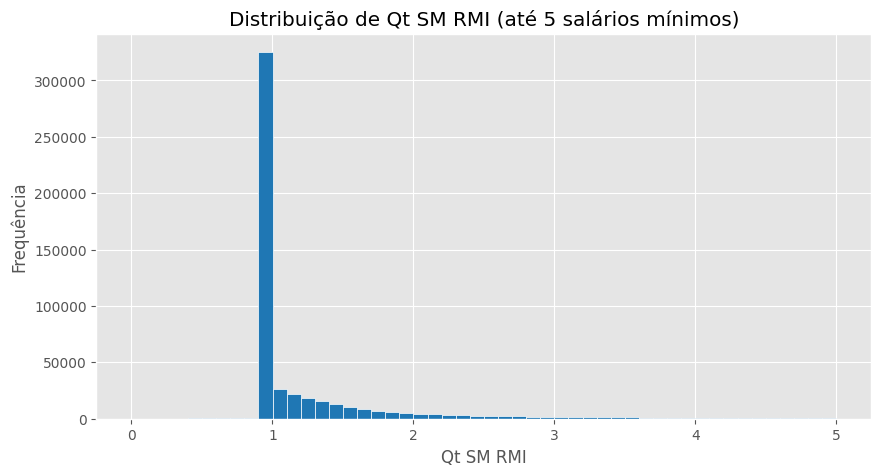

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df.loc[df['qt_sm_rmi'] <= 5, 'qt_sm_rmi'].dropna(), bins=50, color='#1f77b4', edgecolor='white')
ax.set_title('Distribuição de Qt SM RMI (até 5 salários mínimos)')
ax.set_xlabel('Qt SM RMI')
ax.set_ylabel('Frequência')
plt.show()


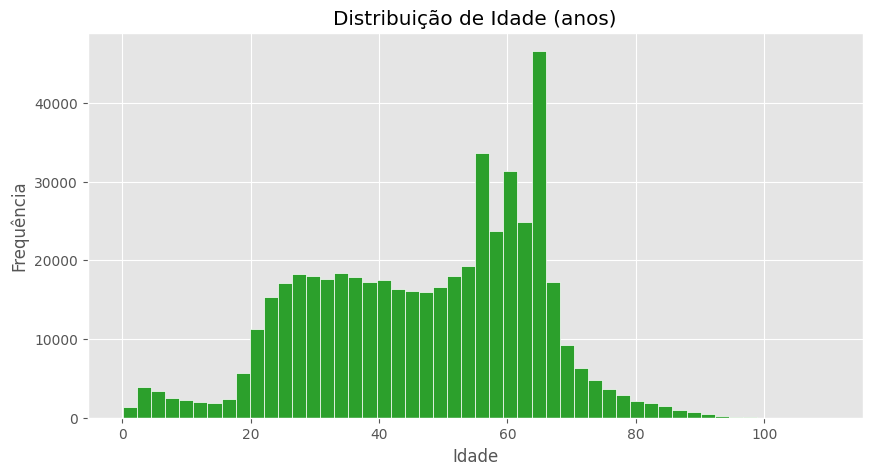

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['idade'].dropna(), bins=50, color='#2ca02c', edgecolor='white')
ax.set_title('Distribuição de Idade (anos)')
ax.set_xlabel('Idade')
ax.set_ylabel('Frequência')
plt.show()


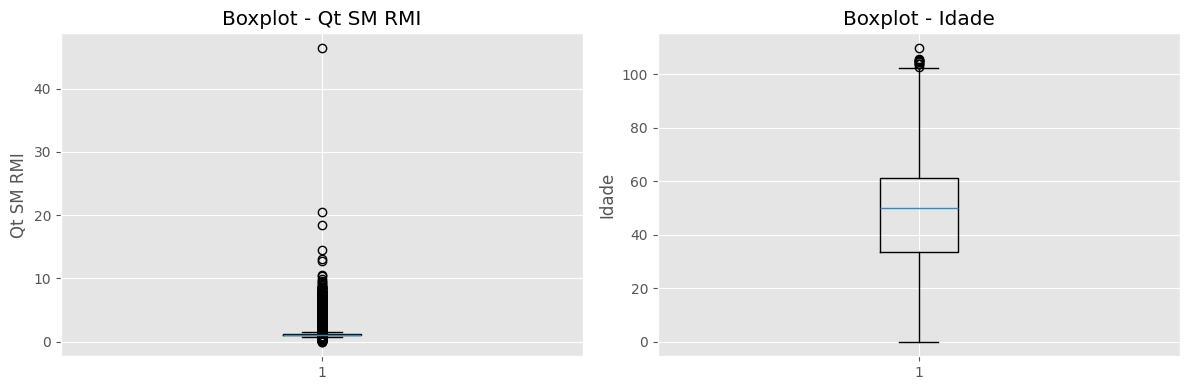

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(df['qt_sm_rmi'].dropna(), vert=True)
axes[0].set_title('Boxplot - Qt SM RMI')
axes[0].set_ylabel('Qt SM RMI')

axes[1].boxplot(df['idade'].dropna(), vert=True)
axes[1].set_title('Boxplot - Idade')
axes[1].set_ylabel('Idade')

plt.tight_layout()
plt.show()


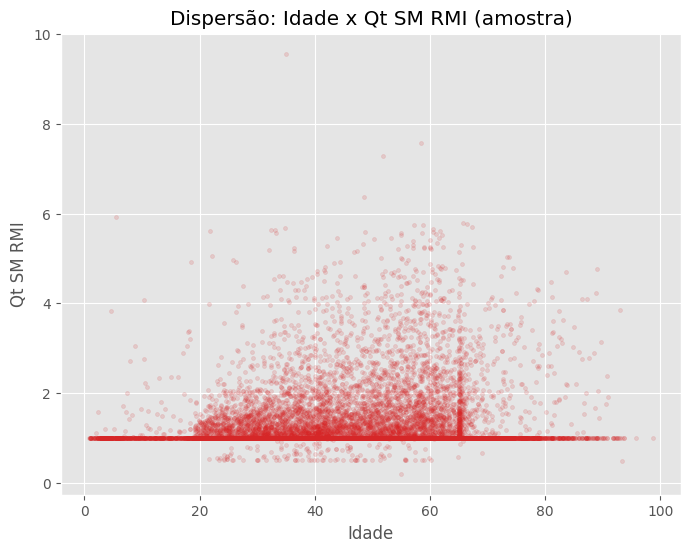

In [14]:
sample = df[['idade', 'qt_sm_rmi']].dropna().sample(n=min(15000, len(df)), random_state=42)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(sample['idade'], sample['qt_sm_rmi'], s=8, alpha=0.15, color='#d62728')
ax.set_title('Dispersão: Idade x Qt SM RMI (amostra)')
ax.set_xlabel('Idade')
ax.set_ylabel('Qt SM RMI')
plt.show()


## Comentarios finais sobre os resultados

No geral, os dados mostram uma concentracao muito forte em beneficios de menor valor: a `qt_sm_rmi` ficou com moda e mediana em 1,0, e media de 1,28. Isso reforca a ideia de que boa parte das concessoes acontece no piso ou perto dele.

A idade ficou bem distribuida entre faixas adultas e idosas, com mediana de 49,98 anos e media de 47,30. A correlacao entre `idade` e `qt_sm_rmi` foi positiva, mas fraca, entao idade sozinha nao explica bem a variacao do valor do beneficio.

Tambem apareceu uma diferenca clara entre categorias: houve mais registros de **Feminino** do que de Masculino, e a clientela **Urbano** foi maior que a Rural. Entre as especies, o maior volume foi de **Auxilio Doenca Previdenciario** nesta competencia.

Sobre qualidade dos dados, nao encontrei valores ausentes nas colunas usadas apos o tratamento. Ainda assim, existem outliers de `qt_sm_rmi`, que podem refletir casos especificos de regra de calculo. Para uma analise mais completa, o ideal seria expandir para varias competencias e comparar a evolucao no tempo.
